# IMPORTING LIBRARIES

In [356]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt, pi
import pdb
from numba import njit
device = 'cpu'

# OLD INTEGRALS

In [357]:
def I2_val(C): # CORRECT
  a = C[0,1]/np.sqrt(1+C[0,0])/np.sqrt(1+C[1,1])
  a = 2*np.asin(a)/np.pi
  return a

def I3_val(C): # CORRECT
  sDel3 = np.sqrt( (1+C[0,0])*(1+C[2,2]) - C[0,2]**2 )
  num = C[1,2]*(1+C[0,0]) - C[0,1]*C[0,2]
  den = 1 + C[0,0]
  return (2*num)/den/sDel3/np.pi

def I4_val(C): # CORRECT
  Del4 = (1+C[0,0])*(1+C[1,1]) - C[0,1]**2
  Del0 = Del4*C[2,3] - C[1,2]*C[1,3]*(1+C[0,0]) - C[0,2]*C[0,3]*(1+C[1,1]) + C[0,1]*C[0,2]*C[1,3] + C[0,1]*C[0,3]*C[1,2]
  Del1 = Del4*(1+C[2,2]) - (C[1,2]**2)*(1+C[0,0]) - (C[0,2]**2)*(1+C[1,1]) + 2*C[0,1]*C[0,2]*C[1,2]
  Del2 = Del4*(1+C[3,3]) - (C[1,3]**2)*(1+C[0,0]) - (C[0,3]**2)*(1+C[1,1]) + 2*C[0,1]*C[0,3]*C[1,3]
  return 4 * np.asin( Del0/np.sqrt(Del1*Del2) ) / np.pi / np.pi / np.sqrt(Del4)

# OLD UPDATES

In [358]:
def old_R(C,h,eta,v,K,M,task='A'):

    if task == 'A':
        delay = K
    else:
        delay = K+M

    ng = np.zeros((K,M)).astype(float)

    for i in range(K):
        for n in range(M):
        
            sum1 = 0
            for m in range(M):
              C_proj = C[[i , K + n , delay + m],:][:,[i , K + n , delay + m]]
              sum1 +=  h[i] * I3_val(C_proj) * v[m]
            
            sum2 = 0
            for k in range(K):
              C_proj = C[[i , K + n , k],:][:,[i , K + n , k]]
              sum2 += h[i] * I3_val(C_proj) * h[k]

            ng[i,n] =  (sum1 - sum2)

    
    return eta * ng

def old_Q(C,h,eta,v,K,M,task='A'):
  ng1 = np.zeros((K,K)).astype(float)
  ng2 = np.zeros((K,K)).astype(float)
  ng3 = np.zeros((K,K)).astype(float)

  if task == 'A':
      delay = K
  else:
      delay = K+M
  
  for i in range(K):
     for k in range(K):
        
        sum1 = 0
        for m in range(M):
          C_proj = C[[i,k,delay+m],:][:,[i,k,delay+m]]
          sum1 += h[i] * v[m] * I3_val(C_proj)

        sum2 = 0
        for j in range(K):
          C_proj = C[[i,k,j],:][:,[i,k,j]]
          sum2 += h[i] * h[j] * I3_val(C_proj)

        ng1[i,k] = sum1 - sum2

        sum3 = 0
        for m in range(M):
          C_proj = C[[k,i,delay+m],:][:,[k,i,delay+m]]
          sum3 += h[k] * v[m] * I3_val(C_proj)

        sum4 = 0
        for j in range(K):
          C_proj = C[[k,i,j],:][:,[k,i,j]]
          sum4 += h[k] * h[j] * I3_val(C_proj)

        ng2[i,k] = sum3 - sum4


        sum5 = 0
        for j in range(K):
          for l in range(K):
            C_proj = C[[i,k,j,l],:][:,[i,k,j,l]]
            sum5 += h[j]*h[l]*I4_val(C_proj)
        
        sum6 = 0
        for m in range(M):
          for n in range(M):
            C_proj = C[[i,k,delay+m,delay+n],:][:,[i,k,delay+m,delay+n]]
            sum6 += v[m]*v[n]*I4_val(C_proj)
        
        sum7 = 0
        for j in range(K):
          for m in range(M):
            C_proj = C[[i,k,j,delay+m],:][:,[i,k,j,delay+m]]
            sum7 += h[j]*v[m]*I4_val(C_proj)
        
        ng3[i,k] = h[k]*h[i]*(sum5 + sum6 - 2 * sum7)

  return eta * (ng1+ng2) + (eta**2)*ng3


def old_U(C,h,eta,v,K,M,task='A'):


    if task == 'A':
        delay = K
    else:
        delay = K + M

    ng = np.zeros((K,M)).astype(float)

    for i in range(K):
        for p in range(M):
        
            sum1 = 0
            for m in range(M):
              C_proj = C[[i , K + M + p , delay + m],:][:,[i , K + M + p , delay + m]]
              sum1 +=  h[i] * I3_val(C_proj) * v[m]
            
            sum2 = 0
            for k in range(K):
              C_proj = C[[i , K + M + p , k],:][:,[i , K + M + p , k]]
              sum2 += h[i] * I3_val(C_proj) * h[k]

            ng[i,p] = sum1 - sum2

    
    return eta * ng

def old_H(C,h,eta,v,K,M,task='A'):
  
  ng = np.zeros((K,)).astype(float)

  if task == 'A':
    delay = K
  else:
    delay = K + M

  for i in range(K):
     sum1 = 0
     for m in range(M):
        C_proj = C[[delay+m,i],:][:,[delay+m,i]]
        sum1 += v[m] * I2_val(C_proj)

     sum2 = 0
     for k in range(K):
        C_proj = C[[k,i],:][:,[k,i]]
        sum2 += h[k] * I2_val(C_proj)
     ng[i] = sum1 - sum2
  
  return eta * ng

# INTEGRALS

In [359]:
@njit
def I2_val_numba(C, a, b):
    cij = C[a, b]
    denom1 = np.sqrt(1.0 + C[a, a])
    denom2 = np.sqrt(1.0 + C[b, b])
    return 2.0 * np.arcsin(cij / denom1 / denom2) / np.pi


@njit
def I3_val_numba(C, a, b, c):
    C00 = C[a,a]
    C11 = C[b,b]
    C22 = C[c,c]
    C02 = C[a,c]
    C01 = C[a,b]
    C12 = C[b,c]

    sDel3 = np.sqrt((1+C00)*(1+C22) - C02*C02)
    num = C12*(1+C00) - C01*C02
    den = 1 + C00
    return (2.0*num)/den/sDel3/np.pi

@njit
def I4_val_numba(C, a, b, c, d):
    Caa = C[a, a]
    Cbb = C[b, b]
    Ccc = C[c, c]
    Cdd = C[d, d]

    Cab = C[a, b]
    Cac = C[a, c]
    Cad = C[a, d]
    Cbc = C[b, c]
    Cbd = C[b, d]
    Ccd = C[c, d]

    Del4 = (1.0 + Caa)*(1.0 + Cbb) - Cab*Cab

    Del0 = (
        Del4*Ccd
        - Cbc*Cbd*(1.0 + Caa)
        - Cac*Cad*(1.0 + Cbb)
        + Cab*Cac*Cbd
        + Cab*Cad*Cbc
    )

    Del1 = (
        Del4*(1.0 + Ccc)
        - (Cbc*Cbc)*(1.0 + Caa)
        - (Cac*Cac)*(1.0 + Cbb)
        + 2.0*Cab*Cac*Cbc
    )

    Del2 = (
        Del4*(1.0 + Cdd)
        - (Cbd*Cbd)*(1.0 + Caa)
        - (Cad*Cad)*(1.0 + Cbb)
        + 2.0*Cab*Cad*Cbd
    )

    return 4.0 * np.asin(Del0 / np.sqrt(Del1*Del2)) \
           / np.pi / np.pi / np.sqrt(Del4)

# UPDATES

### LGS UPDATES

In [360]:
@njit
def update_R(C, h, eta, v, K, M):
    ng = np.zeros((K, M))
    delay = K
    for i in range(K):
        for n in range(M):
            sum1 = 0.0
            for m in range(M):
                sum1 += h[i] * I3_val_numba(C, i, K + n, delay + m) * v[m]
            sum2 = 0.0
            for k in range(K):
                sum2 += h[i] * I3_val_numba(C, i, K + n, k) * h[k]
            ng[i, n] = sum1 - sum2
    return eta * ng

@njit
def update_Q(C, h, eta, v, K, M):
    ng1 = np.zeros((K, K))
    ng2 = np.zeros((K, K))
    ng3 = np.zeros((K, K))
    delay = K
    for i in range(K):
        for k in range(K):
            sum1 = 0.0
            for m in range(M):
                sum1 += h[i] * v[m] * I3_val_numba(C, i, k, delay + m)
            sum2 = 0.0
            for j in range(K):
                sum2 += h[i] * h[j] * I3_val_numba(C, i, k, j)
            ng1[i, k] = sum1 - sum2
            sum3 = 0.0
            for m in range(M):
                sum3 += h[k] * v[m] * I3_val_numba(C, k, i, delay + m)
            sum4 = 0.0
            for j in range(K):
                sum4 += h[k] * h[j] * I3_val_numba(C, k, i, j)
            ng2[i, k] = sum3 - sum4
            sum5 = 0.0
            for j in range(K):
                for l in range(K):
                    sum5 += h[j] * h[l] * I4_val_numba(C, i, k, j, l)
            sum6 = 0.0
            for m in range(M):
                for n in range(M):
                    sum6 += v[m] * v[n] * I4_val_numba(C, i, k, delay + m, delay + n)
            sum7 = 0.0
            for j in range(K):
                for m in range(M):
                    sum7 += h[j] * v[m] * I4_val_numba(C, i, k, j, delay + m)
            ng3[i, k] = h[k] * h[i] * (sum5 + sum6 - 2.0 * sum7)
    return eta * (ng1 + ng2) + (eta * eta) * ng3

@njit
def update_U(C, h, eta, v, K, M):
    ng = np.zeros((K, M))
    delay = K
    for i in range(K):
        for p in range(M):
            sum1 = 0.0
            for m in range(M):
                sum1 += h[i] * I3_val_numba(C, i, K + M + p, delay + m) * v[m]
            sum2 = 0.0
            for k in range(K):
                sum2 += h[i] * I3_val_numba(C, i, K + M + p, k) * h[k]
            ng[i, p] = sum1 - sum2
    return eta * ng

@njit
def update_Ha(C, h, eta, v, K, M):
    ng = np.zeros((K,))
    delay = K
    for i in range(K):
        sum1 = 0.0
        for m in range(M):
            sum1 += v[m] * I2_val_numba(C, delay + m, i)
        sum2 = 0.0
        for k in range(K):
            sum2 += h[k] * I2_val_numba(C, k, i)
        ng[i] = sum1 - sum2
    return eta * ng

### LORA UPDATES

In [361]:
@njit
def update_D(C, h, eta, v, K, M, L, gamma):
    ng = np.zeros((K, L))
    for j in range(K):
        for s in range(L):
            sum1 = 0.0
            for i in range(K):
                sum1 += h[j] * h[i] * I3_val_numba(C, K + j, 2 * K + M + s, K + i)
            sum2 = 0.0
            for m in range(M):
                sum2 += h[j] * v[m] * I3_val_numba(C, K + j, 2 * K + M + s, 2 * K + m)
            ng[j, s] = gamma * eta * (sum2 - sum1)
    return ng

@njit
def update_Gamma(C, h, eta, v, K, M, L, D, gamma):
    ng = np.zeros((M, L))
    for m in range(M):
        for s in range(L):
            sum1 = 0.0
            for i in range(K):
                for l in range(K):
                    sum1 += h[i] * h[l] * D[i, s] * I3_val_numba(C, K + i, 2 * K + m, K + l)
            sum2 = 0.0
            for i in range(K):
                for n in range(M):
                    sum2 += h[i] * v[n] * D[i, s] * I3_val_numba(C, K + i, 2 * K + m, 2 * K + n)
            ng[m, s] = sum2 - sum1
    return eta * gamma * ng

@njit
def update_Lambda(C, h, eta, v, K, M, L, D, gamma):
    ng = np.zeros((M, L))
    for m in range(M):
        for s in range(L):
            sum1 = 0.0
            for i in range(K):
                for l in range(K):
                    sum1 += h[i] * h[l] * D[i, s] * I3_val_numba(C, i, K + m, l)
            sum2 = 0.0
            for i in range(K):
                for n in range(M):
                    sum2 += h[i] * v[n] * D[i, s] * I3_val_numba(C, i, K + m, K + M + n)
            ng[m, s] = sum2 - sum1
    return eta * gamma * ng

@njit
def update_G(C, h, eta, v, K, M, L, D, gamma):
    ng = np.zeros((K, L))
    for j in range(K):
        for s in range(L):
            sum1 = 0.0
            for i in range(K):
                for l in range(K):
                    sum1 += h[i] * h[l] * D[i, s] * I3_val_numba(C, K + i, j, K + l)
            sum2 = 0.0
            for i in range(K):
                for m in range(M):
                    sum2 += h[i] * v[m] * D[i, s] * I3_val_numba(C, K + i, j, 2 * K + m)
            ng[j, s] = sum2 - sum1
    return eta * gamma * ng

@njit
def update_Hb(C, h, eta, v, K, M, L, D):
    ng = np.zeros((K,))
    for j in range(K):
        sum1 = 0.0
        for m in range(M):
            sum1 += v[m] * I2_val_numba(C, 2 * K + m, K + j)
        sum2 = 0.0
        for i in range(K):
            sum2 += h[i] * I2_val_numba(C, K + i, K + j)
        ng[j] = sum1 - sum2
    return eta * ng

@njit
def update_Phi(C, h, eta, v, K, M, L, D, gamma):
    ng = np.zeros((L, L))
    for s in range(L):
        for t in range(s, L):
            sum1 = 0.0
            sum2 = 0.0
            sum3 = 0.0
            sum4 = 0.0
            for i in range(K):
                idx_i = K + i
                for m in range(M):
                    idx_t = 2 * K + M + t
                    idx_m = 2 * K + m
                    sum1 += h[i] * v[m] * D[i, s] * I3_val_numba(C, idx_i, idx_t, idx_m)
            for i in range(K):
                idx_i = K + i
                for k in range(K):
                    idx_t = 2 * K + M + t
                    idx_k = K + k
                    sum2 += h[i] * h[k] * D[i, s] * I3_val_numba(C, idx_i, idx_t, idx_k)
            for i in range(K):
                idx_i = K + i
                for m in range(M):
                    idx_s = 2 * K + M + s
                    idx_m = 2 * K + m
                    sum3 += h[i] * v[m] * D[i, t] * I3_val_numba(C, idx_i, idx_s, idx_m)
            for i in range(K):
                idx_i = K + i
                for k in range(K):
                    idx_s = 2 * K + M + s
                    idx_k = K + k
                    sum4 += h[i] * h[k] * D[i, t] * I3_val_numba(C, idx_i, idx_s, idx_k)
            sum5 = 0.0
            sum6 = 0.0
            sum7 = 0.0
            for i in range(K):
                idx_i = K + i
                for j in range(K):
                    idx_j = K + j
                    for k in range(K):
                        idx_k = K + k
                        for l in range(K):
                            idx_l = K + l
                            sum5 += h[i] * h[j] * h[k] * h[l] * D[i, t] * D[j, s] * I4_val_numba(C, idx_i, idx_j, idx_k, idx_l)
            for i in range(K):
                idx_i = K + i
                for j in range(K):
                    idx_j = K + j
                    for l in range(K):
                        idx_l = K + l
                        for m in range(M):
                            idx_m = 2 * K + m
                            sum6 += h[i] * h[j] * h[l] * v[m] * D[i, t] * D[j, s] * I4_val_numba(C, idx_i, idx_j, idx_l, idx_m)
            for i in range(K):
                idx_i = K + i
                for j in range(K):
                    idx_j = K + j
                    for m in range(M):
                        idx_m = 2 * K + m
                        for n in range(M):
                            idx_n = 2 * K + n
                            sum7 += h[i] * h[j] * v[n] * v[m] * D[i, t] * D[j, s] * I4_val_numba(C, idx_i, idx_j, idx_m, idx_n)
            ng[t, s] = eta * gamma * (sum1 - sum2 + sum3 - sum4) + (eta * eta) * (gamma * gamma) * (sum5 - 2.0 * sum6 + sum7)
            ng[s, t] = ng[t, s]
    return ng

# DEFINITION of Teacher and Student

In [362]:
class Teacher(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Teacher, self).__init__()
        self.D = input_size

        self.fc1 = nn.Linear(input_size, hidden_size, bias=False)

        self.fc2 = nn.Linear(hidden_size, 1, bias=False)

        nn.init.normal_(self.fc1.weight, mean=0.0, std=1)

    def forward(self, x):
        x = self.fc1(x)/(self.D**0.5)
        x = torch.erf(x/sqrt(2))
        x = self.fc2(x)
        return x.unsqueeze(1)

class Student(nn.Module):
    
    def __init__(self, input_size, hidden_size, output_size, beta=1, low_dim=1):
        super(Student, self).__init__()
        self.D = input_size
        self.N = hidden_size
        self.L = low_dim
        self.beta = beta

        self.fc1 = nn.Linear(input_size, hidden_size, bias=False)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.001)

        self.head_1 = nn.Linear(hidden_size, output_size,  bias=False)
        self.head_2 = nn.Linear(hidden_size, output_size,  bias=False)

        nn.init.normal_(self.head_1.weight, mean=0.0, std=0.0001)
        nn.init.normal_(self.head_2.weight, mean=0.0, std=0.0001)

        self.A = nn.Linear(input_size, low_dim, bias = False)
        self.B = nn.Linear(low_dim, hidden_size, bias = False)

        nn.init.normal_(self.A.weight, mean=0.0, std=0.001)
        nn.init.normal_(self.B.weight, mean=0.0, std=0.001)
        
    def forward(self, x, LoRA=False,A_only=False):

        h = self.fc1(x)/(self.D**0.5)
        
        if LoRA:
          
          self.fc1.weight.detach_()

          if A_only:
              
              self.B.weight.detach_()

          l = self.A(x)/(self.D**0.5)
          l = self.B(l)
          h = h + (self.beta/sqrt(self.L)) * l

        h = torch.erf(h/sqrt(2))

        o1 = self.head_1(h)
        o2 = self.head_2(h)

        return o1, o2

class Data_and_Teachers():
    
    def __init__(self, input_size, hidden_size, rho, random_heads=False):
        self.input_size = input_size
        self.hidden = hidden_size
        self.rho = rho
        self.teacher_1 = Teacher(input_size, hidden_size)
        self.teacher_2 = Teacher(input_size, hidden_size)
        self.dist = torch.distributions.MultivariateNormal(torch.zeros(self.input_size), torch.eye(self.input_size))
        self.random_heads = random_heads

    def get_Teachers(self):

        # take random initialised teacher
        self.wt1 = self.teacher_1.fc1.weight.data


        # take a orthogonal vector
        r = torch.randn_like(self.wt1)

        # Combine w1 and r with overlap rho
        wt2 = self.rho * self.wt1 + torch.sqrt(1 - torch.tensor([self.rho])**2) * r

        # obtain w2 and update the weights
        self.teacher_2.fc1.weight.data = wt2

        # set the output layer to +1, -1
        if self.random_heads:
            self.teacher_1.fc2.weight.data = torch.randn((self.hidden,))
            self.teacher_2.fc2.weight.data = torch.randn((self.hidden,))
        else:
            self.teacher_1.fc2.weight.data = 1 + 0.01*torch.randn((self.hidden,))
            self.teacher_2.fc2.weight.data = -1 + 0.01*torch.randn((self.hidden,))

        return self.teacher_1, self.teacher_2

    def get_data(self):
        
        self.datum = torch.randn((1, self.input_size)).to(device) # sample x

        self.yt1 = self.teacher_1(self.datum).detach() # obtain y from teacher 1
        self.yt2 = self.teacher_2(self.datum).detach() # obtain y from teacher 2

        return self.datum, self.yt1, self.yt2

    def get_target(self, x):    # get only targets given x
        y1 = self.teacher_1(x).detach()
        y2 = self.teacher_2(x).detach()
        return y1, y2

In [363]:
# function to compute test error on a given batch of size 'pop'
# here data is the object from the class above
def Test_err(model, pop, loss, data_and_teach, LoRA=False):
  with torch.no_grad():
    #x = dist.sample((pop,)).to(device)
    x = torch.randn((pop, data.input_size)).to(device)
    y1, y2 = data_and_teach.get_target(x)

  y_pred1, y_pred2 = model(x, LoRA=LoRA)
  l1 = 0.5*loss(y_pred1, y1)
  l2 = 0.5*loss(y_pred2, y2)

  return l1.item(), l2.item()

# TRAINING NETWORKS

In [364]:
K = 2
M = 1
L = 1

N = 3000
dist = torch.distributions.MultivariateNormal(torch.zeros(N), torch.eye(N))

torch.manual_seed((K+M+L+200)*N//3)

A_only = True
random_heads = False

rho = 0.5
alpha1 = 150
alpha2 = 150
beta = 1

gamma = beta/sqrt(L)
data = Data_and_Teachers(N, M, rho, random_heads=random_heads)
t1, t2 = data.get_Teachers()
t1.to(device)
t2.to(device)
print('Empirical rho:', (t1.fc1.weight @ t2.fc1.weight.T)/N)

stud = Student(N, K, 1, beta, low_dim=L)

# SAVING TEACHERS
B_a = data.teacher_1.fc1.weight.detach().numpy().copy()
B_b = data.teacher_2.fc1.weight.detach().numpy().copy()
v_a = data.teacher_1.fc2.weight.detach().numpy().copy()
v_b = data.teacher_2.fc2.weight.detach().numpy().copy()

# SAVING ORDER PARAMETERS FOR NUMERICAL INTEGRATION (LGS)
W0 = stud.fc1.weight.detach().numpy().copy()

Q0 = ((W0 @ W0.T)/N)
Q_list = [Q0]
R0 = ((W0 @ B_a.T)/N)
R_list = [R0]
T0 = ((B_a @ B_a.T)/N)
T_list = [T0]
U0 = ((W0 @ B_b.T)/N)
U_list = [U0]
S0 = ((B_b @ B_b.T)/N)
S_list = [S0]
V0 = ((B_a @ B_b.T)/N)
V_list = [V0]

Ha0 = stud.head_1.weight.detach().numpy().flatten().copy()
Ha_list = [Ha0]

stud.to(device)

# LEARNING RATES FOR TRAINING PROCEDURES:
alpha_W = 1.2
alpha_H = 1.2
alpha_a = 1.2
alpha_b = 1.2

opt = torch.optim.SGD( [

    {"params": stud.fc1.parameters(), "lr": alpha_W},

    {"params": stud.A.parameters(), "lr": alpha_a},

    {"params": stud.B.parameters(), "lr": alpha_b/N},

    {"params": stud.head_1.parameters(), "lr": alpha_H/N},

    {"params": stud.head_2.parameters(), "lr": alpha_H/N},] )

loss = nn.MSELoss()
loss1_hist = []
loss2_hist = []
test_loss1_hist = []
test_loss2_hist = []

number = N
steps = torch.arange(0, (alpha1+alpha2)*N, number)
P_test = 5 * number
test = Test_err(stud, P_test, loss, data)

print('Starting Task 1 ----------------------')
print('Test Loss on Task 1:', test[0])
print('Test Loss on Task 2:', test[1], '\n')

# FIRST PHASE OF TRAINING:
for i in range( alpha1 * N ):

  if i % number == 0:
    test = Test_err(stud, P_test, loss, data)
    test_loss1_hist.append(test[0])
    test_loss2_hist.append(test[1])

    W_curr = stud.fc1.weight.detach().numpy().copy()
    Ha_curr = stud.head_1.weight.detach().numpy().flatten().copy()
    Q_list.append( ((W_curr @ W_curr.T)/N).copy() )
    R_list.append(  ( (W_curr @ B_a.T )/N).copy() )
    U_list.append(  ( (W_curr @ B_b.T )/N).copy() )
    Ha_list.append( Ha_curr )
  
  x, y1, y2 = data.get_data()
  opt.zero_grad()

  y_pred1, y_pred2 = stud(x.to(device))
  l1 = 0.5*loss(y_pred1, y1)

  l2 = 0.5*loss(y_pred2, y2)

  l1.backward()
  opt.step()

last_errA = test_loss1_hist[-1]
last_errB = test_loss2_hist[-1]
test = Test_err(stud, P_test, loss, data)
print('Starting Task 2 ----------------------')
print('Test Loss on Task 1:', test[0])
print('Test Loss on Task 2:', test[1], '\n')

w1 = stud.fc1.weight.data

if A_only:
  val,idx = torch.topk( torch.abs(stud.head_1.weight), K - L )
  with torch.no_grad():
    k = 0
    for i in range(K):
      if i in idx:
        stud.B.weight[i,:] = 0
      else:
        stud.B.weight[i,:] = 0
        stud.B.weight[i,k % L] = 1
        k += 1

# LORA ORDER PARAMETERS
D0 = stud.B.weight.detach().numpy().copy()
D_list = []
A0 = stud.A.weight.detach().numpy().copy()
G0 = ((W0 @ A0.T)/N).copy()
G_list = []
Lam0 = ((B_a @ A0.T)/N).copy()
Lambda_list = []
Gam0 = ((B_b @ A0.T)/N).copy()
Gamma_list = []
Phi0 = ((A0  @ A0.T)/N).copy()
Phi_list = []
Hb0 = stud.head_2.weight.detach().numpy().flatten().copy()
Hb_list = [Hb0]
Ha02 = stud.head_1.weight.detach().numpy().flatten().copy()

# ENABLE LORA UPDATE

LoRA = True

# SECOND PHASE OF TRAINING:
for i in range( alpha2 * N ):
  
  if i % number == 0:
    test = Test_err(stud, P_test, loss, data, LoRA)
    test_loss1_hist.append(test[0])
    test_loss2_hist.append(test[1])

    W0 = stud.fc1.weight.detach().numpy().copy()
    A_curr = stud.A.weight.detach().numpy().copy()
    B_curr = stud.B.weight.detach().numpy().copy()
    Hb_curr = stud.head_2.weight.detach().numpy().flatten().copy()

    D_list.append( B_curr )
    Hb_list.append( Hb_curr )
    G_list.append(((W0 @ A_curr.T)/N))
    Phi_list.append(((A_curr @ A_curr.T)/N))
    Gamma_list.append((( B_b @ A_curr.T)/N))
    Lambda_list.append((( B_a @ A_curr.T)/N))

  x, y1, y2 = data.get_data()
  opt.zero_grad()

  y_pred1, y_pred2 = stud( x.to(device), LoRA=LoRA, A_only=A_only )
  l1 = 0.5*loss(y_pred1, y1)
  loss1_hist.append(l1.item())

  l2 = 0.5*loss(y_pred2, y2)
  loss2_hist.append(l2.item())

  l2.backward()
  opt.step()

test = Test_err(stud, P_test, loss, data, LoRA)
print('End of Task 2 ----------------------')
print('Test Loss on Task 1:', test[0])
print('Test Loss on Task 2:', test[1], '\n')
w2 = stud.fc1.weight.data
print(torch.abs(w1-w2))

Empirical rho: tensor([[0.5224]], grad_fn=<DivBackward0>)
Starting Task 1 ----------------------
Test Loss on Task 1: 0.16947421431541443
Test Loss on Task 2: 0.16377662122249603 

Starting Task 2 ----------------------
Test Loss on Task 1: 5.74981422687415e-05
Test Loss on Task 2: 0.16393795609474182 

End of Task 2 ----------------------
Test Loss on Task 1: 0.03811997175216675
Test Loss on Task 2: 3.2168602501769783e-06 

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


# PLOTS

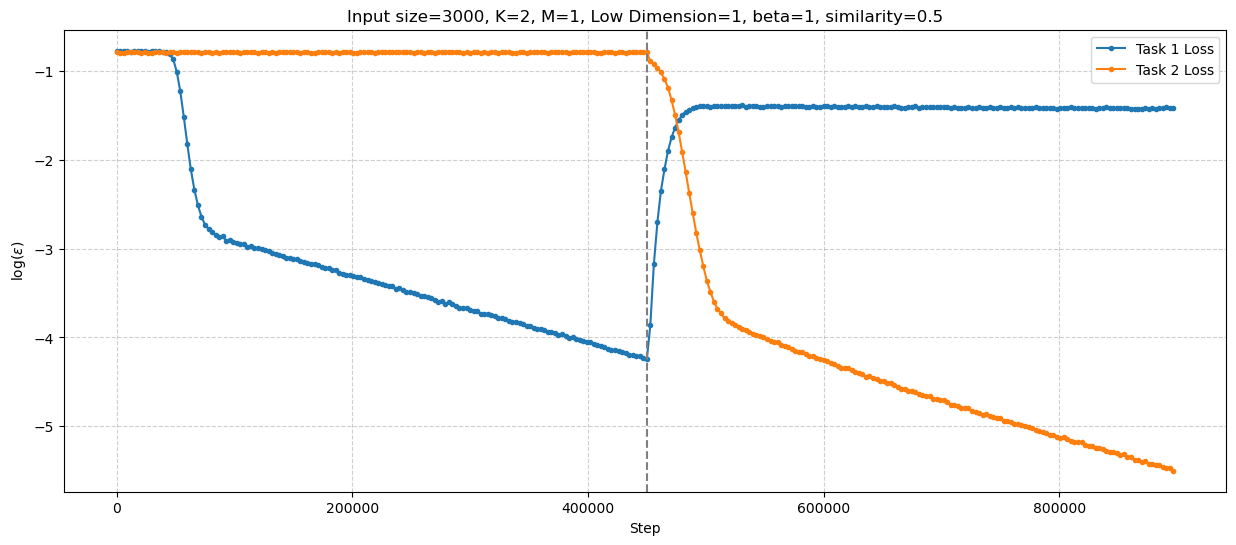

In [365]:
plt.figure(figsize=(15,6))
plt.plot(steps, torch.log10(torch.tensor(test_loss1_hist)),'o-', markersize=3,label='Task 1 Loss')
plt.plot(steps, torch.log10(torch.tensor(test_loss2_hist)),'o-', markersize=3, label='Task 2 Loss')
plt.axvline(x = alpha1*N, linestyle ='--', color = 'gray')
plt.grid(alpha=0.6, linestyle='--')
plt.title(f'Input size={N}, K={K}, M={M}, Low Dimension={L}, beta={beta}, similarity={rho}')
plt.xlabel(r'Step')
plt.ylabel(r'$\log(\epsilon)$')
plt.legend()
plt.show()

# LGS SOLUTION OF ODEs

In [366]:
integration_step = 0.05
num_steps = int( alpha1 / integration_step)

Q = Q0
Q = Q.reshape((K,K))
R = R0
R = R.reshape((K,M))
U = U0
U = U.reshape((K,M))
V = V0
V = V.reshape((M,M))
T = T0
T = T.reshape((M,M))
S = S0
S = S.reshape((M,M))
Ha = Ha0
Ha = Ha.flatten()
Hb = Hb0
Hb = Hb.flatten()

v_a = v_a.flatten()
v_b = v_b.flatten()

R_num = [R]
Q_num = [Q]
U_num = [U]
Ha_num = [Ha]

LossA_num = []
LossB_num = []

for step in range(num_steps):
  
  if step % 100 == 0:
    print(f"Integration step {step} over {num_steps}")

  R1 = np.concatenate([Q , R, U],axis=1)
  R2 = np.concatenate([R.T,T,V],axis=1)
  R3 = np.concatenate([U.T,V.T,S],axis=1)
  C = np.concatenate( [R1,R2,R3],axis=0 )

  lossA = ( sum( [ I2_val(C[[i,k],:][:,[i,k]])*Ha[i]*Ha[k] for i in range(K) for k in range(K) ] )   ) + (
          sum( [ I2_val(C[[K+n,K+m],:][:,[K+n,K+m]])*v_a[m]*v_a[n] for m in range(M) for n in range(M) ] )
        ) - 2*(
          sum( [ I2_val(C[[k,K+n],:][:,[k,K+n]])*Ha[k]*v_a[n] for k in range(K) for n in range(M) ] )
        )

  lossB = ( sum( [ I2_val(C[[i,k],:][:,[i,k]])*Hb[i]*Hb[k] for i in range(K) for k in range(K) ] )   ) + (
        sum( [ I2_val(C[[K+M+n,K+M+m],:][:,[K+M+n,K+M+m]])*v_b[m]*v_b[n] for m in range(M) for n in range(M) ] )
      ) - 2*(
        sum( [ I2_val(C[[k,K+M+n],:][:,[k,K+M+n]])*Hb[k]*v_b[n] for k in range(K) for n in range(M) ] )
      )

  LossB_num.append(lossB/2)
  LossA_num.append(lossA/2)

  R = R + integration_step * update_R(C,Ha,alpha_W,v_a,K,M)
  R_num.append(R)

  Q = Q + integration_step * update_Q(C,Ha,alpha_W,v_a,K,M)
  Q_num.append(Q)

  U = U + integration_step * update_U(C,Ha,alpha_W,v_a,K,M)
  U_num.append(U)

  Ha = Ha + integration_step * update_Ha(C,Ha,alpha_H,v_a,K,M)
  Ha_num.append(Ha.flatten())

t_spanA = N * np.arange(0,alpha1,integration_step)

Integration step 0 over 3000
Integration step 100 over 3000
Integration step 200 over 3000
Integration step 300 over 3000
Integration step 400 over 3000
Integration step 500 over 3000
Integration step 600 over 3000
Integration step 700 over 3000
Integration step 800 over 3000
Integration step 900 over 3000
Integration step 1000 over 3000
Integration step 1100 over 3000
Integration step 1200 over 3000
Integration step 1300 over 3000
Integration step 1400 over 3000
Integration step 1500 over 3000
Integration step 1600 over 3000
Integration step 1700 over 3000
Integration step 1800 over 3000
Integration step 1900 over 3000
Integration step 2000 over 3000
Integration step 2100 over 3000
Integration step 2200 over 3000
Integration step 2300 over 3000
Integration step 2400 over 3000
Integration step 2500 over 3000
Integration step 2600 over 3000
Integration step 2700 over 3000
Integration step 2800 over 3000
Integration step 2900 over 3000


# PLOT FIRST HALF

## GENERALIZATION ERROR

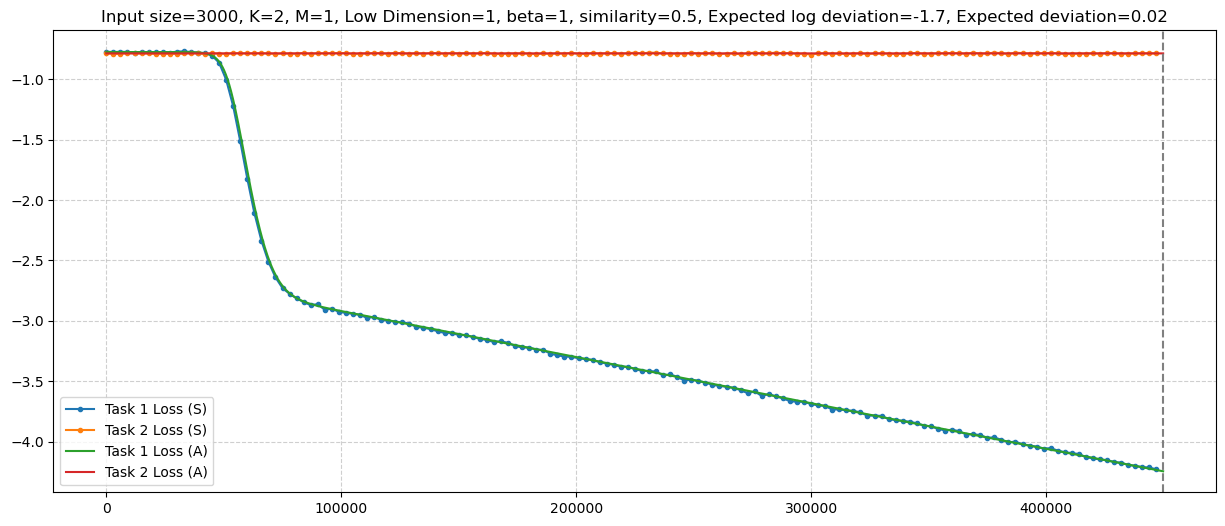

In [367]:
idx = (alpha1*N)//number
plt.figure(figsize=(15,6))
plt.plot(steps[:idx], torch.log10( torch.tensor(test_loss1_hist)[:idx]),'o-', markersize=3,label='Task 1 Loss (S)')
plt.plot(steps[:idx], torch.log10( torch.tensor(test_loss2_hist)[:idx]),'o-', markersize=3, label='Task 2 Loss (S)')

plt.plot(t_spanA,np.log10( np.stack(LossA_num) ),label='Task 1 Loss (A)')
plt.plot(t_spanA,np.log10( np.stack(LossB_num) ),label='Task 2 Loss (A)')

plt.axvline(x = alpha1*N, linestyle ='--', color = 'gray')
plt.grid(alpha=0.6, linestyle='--')
plt.title(f'Input size={N}, K={K}, M={M}, Low Dimension={L}, beta={beta}, similarity={rho}, Expected log deviation={np.log10(1/sqrt(N)):.1f}, Expected deviation={1/sqrt(N):.2f}')
plt.legend()
plt.show()

## ORDER PARAMETERS

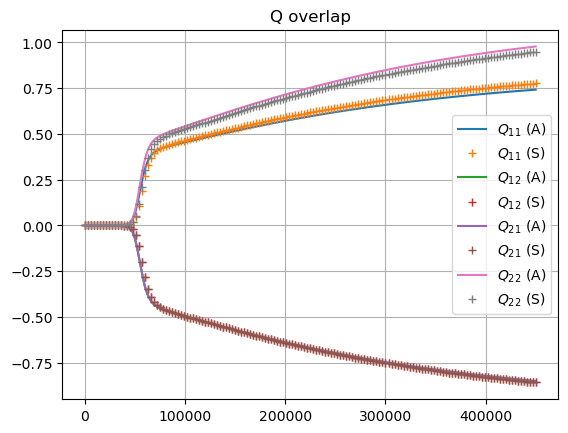

In [368]:
Qs = np.stack(Q_list,axis=2)
idx = (alpha1*N)//number
for m in range(K):
    for s in range(K):
        label = r'$Q_{'+f'{m+1}{s+1}'+r'}$'
        plt.plot(t_spanA , np.stack(Q_num,axis=2)[m,s,:-1],label=label+' (A)')
        plt.plot(steps[:idx+1],Qs[m,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Q overlap')
plt.show()

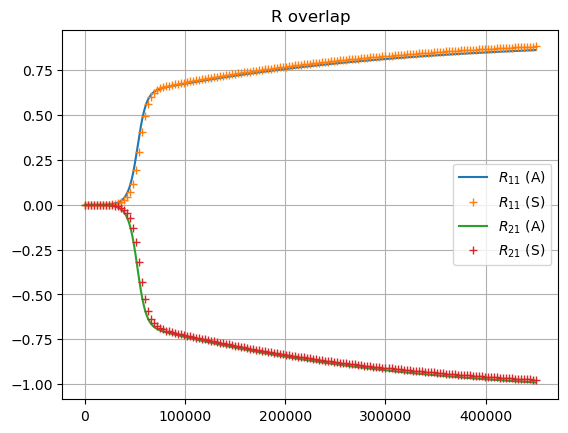

In [369]:
Rs = np.stack(R_list,axis=2)
idx = (alpha1*N)//number
for m in range(K):
    for s in range(M):
        label = r'$R_{'+f'{m+1}{s+1}'+r'}$'
        plt.plot(t_spanA , np.stack(R_num,axis=2)[m,s,:-1],label=label+' (A)')
        plt.plot(steps[:idx+1],Rs[m,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('R overlap')
plt.show()

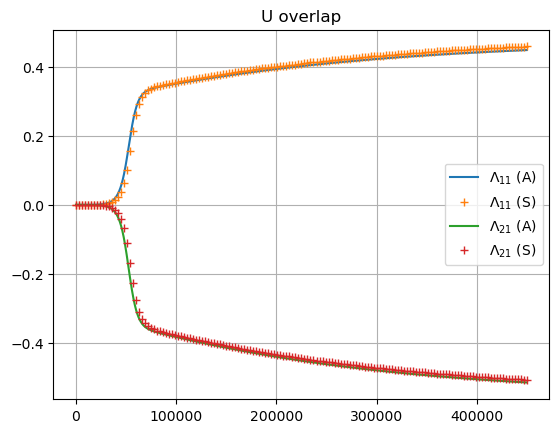

In [370]:
Us = np.stack(U_list,axis=2)
idx = (alpha1*N)//number
for m in range(K):
    for s in range(M):
        label = r'$\Lambda_{'+f'{m+1}{s+1}'+r'}$'
        plt.plot(t_spanA , np.stack(U_num,axis=2)[m,s,:-1],label=label+' (A)')
        plt.plot(steps[:idx+1],Us[m,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('U overlap')
plt.show()

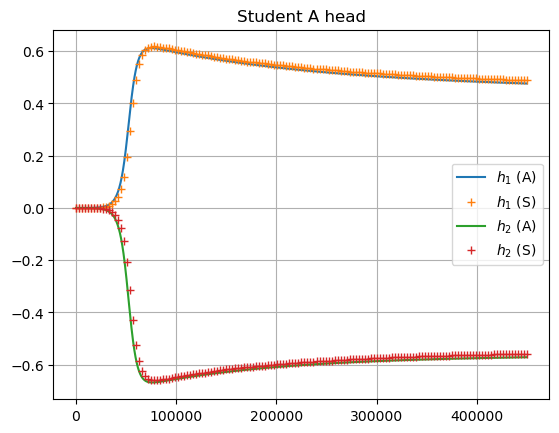

In [371]:
Has = np.stack(Ha_list,axis=1)
for i in range(K):
    label = r'$h_{'+f'{i+1}'+r'}$'
    plt.plot(t_spanA,np.stack(Ha_num)[:-1,i],label=label+' (A)')
    plt.plot(steps[:idx+1],Has[i,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Student A head')
#plt.savefig('Student_B_head.png')
plt.show()

# LORA SOLUTION OF ODEs

In [372]:
integration_step = 0.05
num_steps = int( alpha2 / integration_step)

v_a = data.teacher_1.fc2.weight.detach().numpy().reshape((M)).copy()
v_b = data.teacher_2.fc2.weight.detach().numpy().reshape((M)).copy()

Hb = Hb0.copy()

Gamma = Gam0.copy()
Phi = Phi0.copy()
Lambda = Lam0.copy()
G = G0.copy()
D = D0.copy()

D_num = [D]
Ha_num = [Ha]
Hb_num = [Hb]
G_num = [G]
Phi_num = [Phi]
Gamma_num = [Gamma]
Lambda_num = [Lambda]

for step in range(num_steps):
  
  if step % 100 == 0:
    print(f"Integration step {step} over {num_steps}")

  R1 = np.concatenate([ Q, Q + gamma*G @ D.T , U , G],axis=1)
  R2 = np.concatenate([ Q.T + gamma * D @ G.T, Q + gamma*(G @ D.T + D @ G.T) + (gamma**2) * D @ Phi @ D.T , U + gamma * D @ Gamma.T , G + gamma * D @ Phi.T ],axis=1)
  R3 = np.concatenate([ U.T , U.T + gamma *  Gamma @ D.T , S, Gamma ],axis=1)
  R4 = np.concatenate([ G.T , G.T + gamma * Phi @ D.T , Gamma.T , Phi ],axis=1)
  C = np.concatenate([R1,R2,R3,R4],axis=0)

  lossB = (  np.sum([   Hb[i]*Hb[j]*I2_val( C[[K+i,K+j],:][:,[K+i,K+j]] )  for i in range(K) for j in range(K) ]) 
  - 2 * np.sum([   Hb[i]*v_b[m]*I2_val( C[[K+i,2*K+m],:][:,[K+i,2*K+m]] )  for i in range(K) for m in range(M)     ])
  + np.sum([ v_b[m]*v_b[n]*I2_val( C[[2*K+m,2*K+n],:][:,[2*K+m,2*K+n]] )  for m in range(M) for n in range(M) ])  ).item()

  R1_a = np.concatenate([ Q + gamma*(G @ D.T + D @ G.T) + (gamma**2) * D @ Phi @ D.T , R + gamma * D @ Lambda.T , U + gamma * D @ Gamma.T],axis=1)
  R2_a = np.concatenate([ R.T + gamma * Lambda @ D.T, T , V ],axis=1)
  R3_a = np.concatenate([ U.T + gamma * Gamma @ D.T , V.T, S ],axis=1)
  C_a = np.concatenate([R1_a,R2_a,R3_a],axis=0)

  lossA = (  np.sum([   Ha[i]*Ha[j]*I2_val( C_a[[i,j],:][:,[i,j]] )  for i in range(K) for j in range(K) ]) 
  - 2 * np.sum([   Ha[i]*v_a[m]*I2_val( C_a[[i,K+m],:][:,[i,K+m]] )  for i in range(K) for m in range(M)     ])
  + np.sum([ v_a[m]*v_a[n]*I2_val( C_a[[K+m,K+n],:][:,[K+m,K+n]] )  for m in range(M) for n in range(M) ])  ).item()

  LossB_num.append(lossB/2)
  LossA_num.append(lossA/2)
    
  Phi = Phi + integration_step * update_Phi(C,Hb,alpha_a,v_b,K,M,L,D,gamma)
  Phi_num.append(Phi)

  Gamma = Gamma + integration_step * update_Gamma(C,Hb,alpha_a,v_b,K,M,L,D,gamma)
  Gamma_num.append(Gamma)

  Lambda = Lambda + integration_step * update_Lambda(C_a,Hb,alpha_a,v_b,K,M,L,D,gamma)
  Lambda_num.append(Lambda)

  G = G + integration_step * update_G(C,Hb,alpha_a,v_b,K,M,L,D,gamma)
  G_num.append(G)

  Hb = Hb + integration_step * update_Hb(C,Hb,alpha_H,v_b,K,M,L,D)
  Hb_num.append(Hb)

  if A_only:
    D = D
  else:
    D = D + integration_step * update_D(C,Hb,alpha_b,v_b,K,M,L,gamma)
  D_num.append(D)

  Ha = Ha
  Ha_num.append(Ha)
t_span = N * np.arange( 0 , alpha1+alpha2 , integration_step)

Integration step 0 over 3000
Integration step 100 over 3000
Integration step 200 over 3000
Integration step 300 over 3000
Integration step 400 over 3000
Integration step 500 over 3000
Integration step 600 over 3000
Integration step 700 over 3000
Integration step 800 over 3000
Integration step 900 over 3000
Integration step 1000 over 3000
Integration step 1100 over 3000
Integration step 1200 over 3000
Integration step 1300 over 3000
Integration step 1400 over 3000
Integration step 1500 over 3000
Integration step 1600 over 3000
Integration step 1700 over 3000
Integration step 1800 over 3000
Integration step 1900 over 3000
Integration step 2000 over 3000
Integration step 2100 over 3000
Integration step 2200 over 3000
Integration step 2300 over 3000
Integration step 2400 over 3000
Integration step 2500 over 3000
Integration step 2600 over 3000
Integration step 2700 over 3000
Integration step 2800 over 3000
Integration step 2900 over 3000


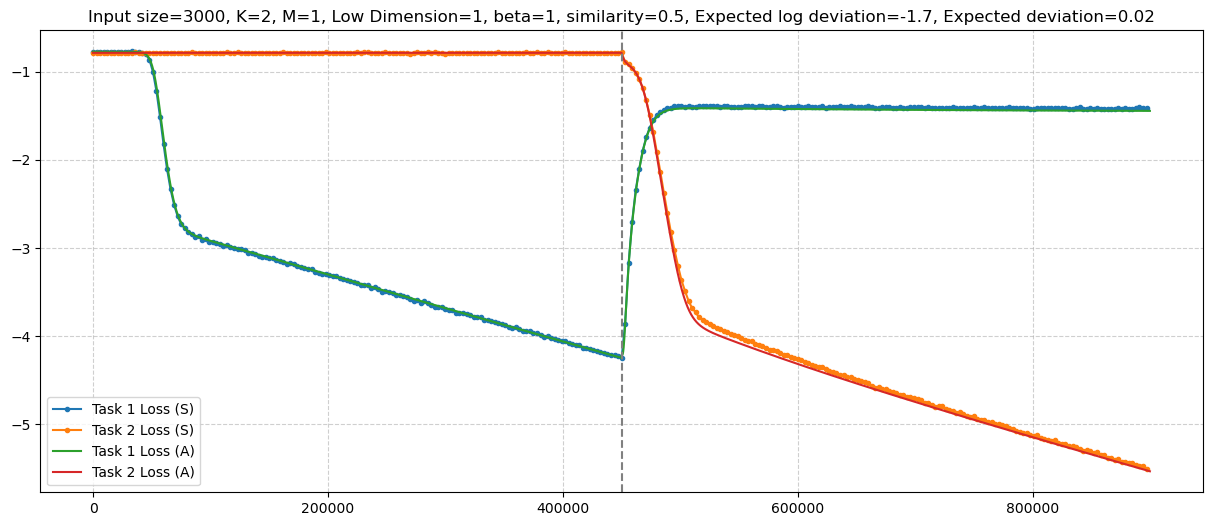

In [373]:
plt.figure(figsize=(15,6))
plt.plot(steps, torch.log10(torch.tensor(test_loss1_hist)),'o-', markersize=3,label='Task 1 Loss (S)')
plt.plot(steps, torch.log10(torch.tensor(test_loss2_hist)),'o-', markersize=3, label='Task 2 Loss (S)')

plt.plot(t_span, np.log10(np.stack(LossA_num)),label='Task 1 Loss (A)')
plt.plot(t_span, np.log10(np.stack(LossB_num)),label='Task 2 Loss (A)')


plt.axvline(x = alpha1*N, linestyle ='--', color = 'gray')
plt.grid(alpha=0.6, linestyle='--')
plt.title(f'Input size={N}, K={K}, M={M}, Low Dimension={L}, beta={beta}, similarity={rho}, Expected log deviation={np.log10(1/sqrt(N)):.1f}, Expected deviation={1/sqrt(N):.2f}')
plt.legend()
plt.show()

## LORA PLOTS

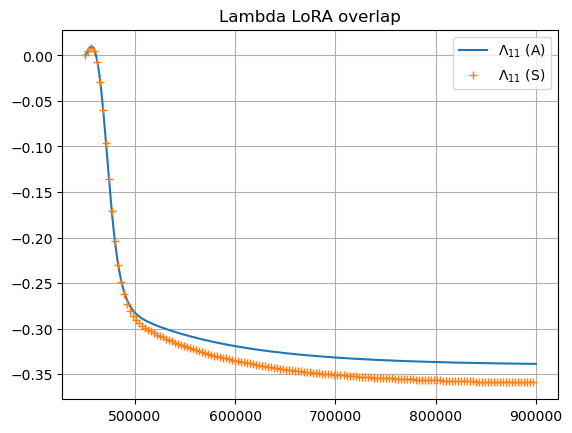

In [374]:
Lambdas = np.stack(Lambda_list,axis=2)
idx = (alpha1*N)//number
for m in range(M):
    for s in range(L):
        label = r'$\Lambda_{'+f'{m+1}{s+1}'+r'}$'
        plt.plot(t_span[len(t_span)//2:],np.stack(Lambda_num,axis=2)[m,s,:-1],label=label+' (A)')
        plt.plot(steps[idx:],Lambdas[m,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Lambda LoRA overlap')
plt.show()

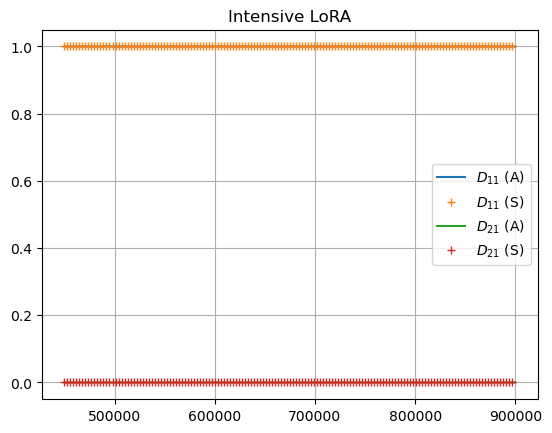

In [375]:
Ds = np.stack(D_list,axis=2)
for i in range(K):
    for s in range(L):
        label = r'$D_{'+f'{i+1}{s+1}'+r'}$'
        plt.plot(t_span[len(t_span)//2:],np.stack(D_num,axis=2)[i,s,:-1],label=label+' (A)')
        plt.plot(steps[idx:],Ds[i,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Intensive LoRA')
#plt.savefig('Intensive_LoRA.png')
plt.show()

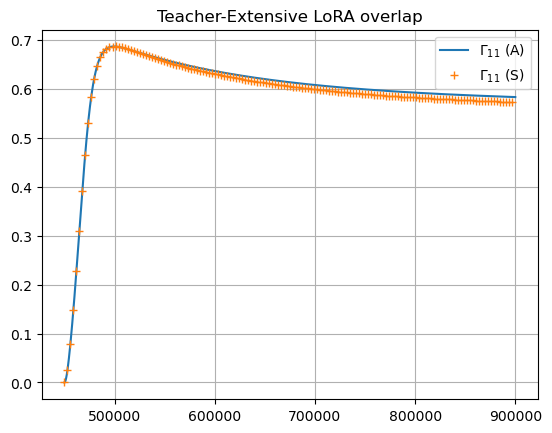

In [376]:
Gammas = np.stack(Gamma_list,axis=2)
for m in range(M):
    for s in range(L):
        label = r'$\Gamma_{'+f'{m+1}{s+1}'+r'}$'
        plt.plot(t_span[len(t_span)//2:],np.stack(Gamma_num,axis=2)[m,s,:-1],label=label+' (A)')
        plt.plot(steps[idx:],Gammas[m,s,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Teacher-Extensive LoRA overlap')
#plt.savefig('Teacher-Extensive_LoRA_overlap.png')
plt.show()

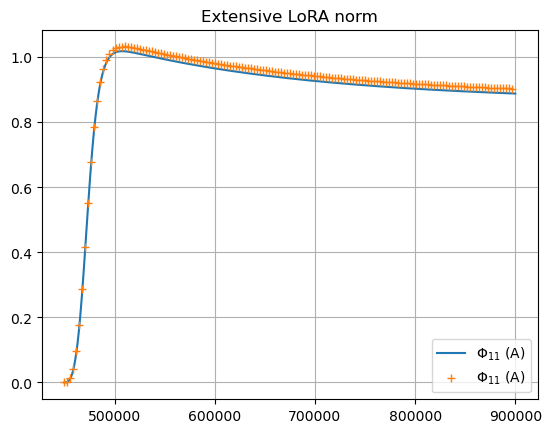

In [377]:
Phis = np.stack(Phi_list,axis=2)
for s in range(L):
    for t in range(L):
        label = r'$\Phi_{'+f'{s+1}{t+1}'+r'}$'
        plt.plot(t_span[len(t_span)//2:],np.stack(Phi_num,axis=2)[s,t,:-1],label=label+' (A)')
        plt.plot(steps[idx:],Phis[s,t,:],'+',label=label+' (A)')
plt.legend()
plt.grid()
plt.title('Extensive LoRA norm')
#plt.savefig('Extensive_LoRA_norm.png')
plt.show()

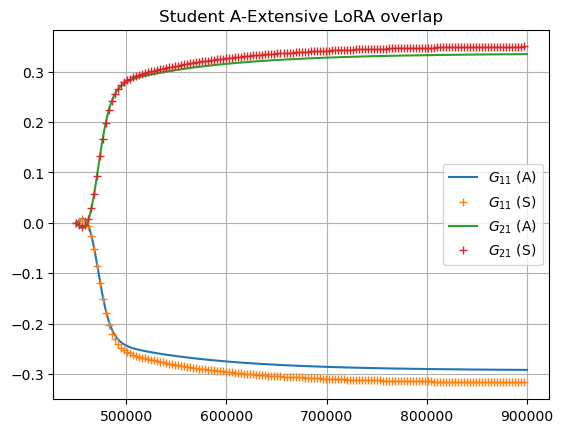

In [378]:
Gs = np.stack(G_list,axis=2)
for i in range(K):
    for k in range(L):
        label = r'$G_{'+f'{i+1}{k+1}'+r'}$'
        plt.plot(t_span[len(t_span)//2:],np.stack(G_num,axis=2)[i,k,:-1],label=label+' (A)')
        plt.plot(steps[idx:],Gs[i,k,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Student A-Extensive LoRA overlap')
#plt.savefig('Student_A-Extensive_LoRA.png')
plt.show()

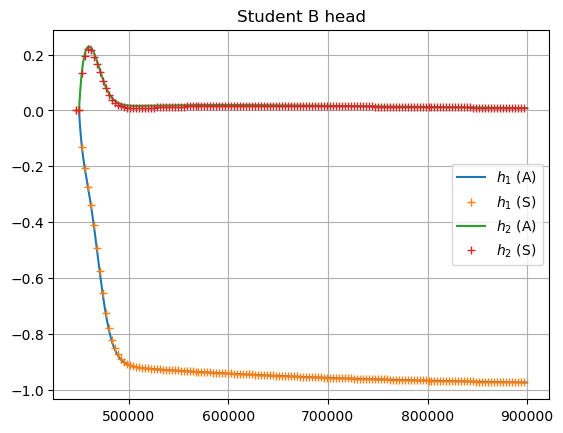

In [379]:
Hbs = np.stack(Hb_list,axis=1)
for i in range(K):
    label = r'$h_{'+f'{i+1}'+r'}$'
    plt.plot(t_span[len(t_span)//2:],np.stack(Hb_num)[:-1,i],label=label+' (A)')
    plt.plot(steps[idx-1:],Hbs[i,:],'+',label=label+' (S)')
plt.legend()
plt.grid()
plt.title('Student B head')
#plt.savefig('Student_B_head.png')
plt.show()